# 03 · Phân Tích Cơ Bản (Fundamental Analysis)
**Cổ phiếu**: FPT, CMG, ELC, ITD  
**Nội dung**:
- Nhóm 1 · Valuation: P/E vs EPS Growth (PEG), Bubble Chart P/E vs BVPS  
- Nhóm 2 · Profitability: EPS Trend, ROE/ROA Bar, ROS & ROEA Line, EPS vs Price Dual-Axis  
- Nhóm 3 · Leverage & Liquidity: D/E, Current Ratio, Beta Clustering  
- Nhóm 4 · CANSLIM Scoring

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os, json, glob

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath('')          # thư mục chứa notebook
DATA_NEW  = os.path.join(BASE_DIR, 'data_new')
DATA_RAW  = os.path.join(BASE_DIR, 'data_raw')
IMG_DIR   = os.path.join(BASE_DIR, 'img')
os.makedirs(IMG_DIR, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',   'axes.labelcolor': '#C9D1D9',
    'axes.titlecolor': '#FFFFFF',  'xtick.color': '#8B949E',
    'ytick.color': '#8B949E',      'text.color': '#C9D1D9',
    'grid.color': '#21262D',       'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D', 'font.family': 'DejaVu Sans',
})

TICKERS = ['FPT', 'CMG', 'ELC', 'ITD']
COLORS  = {'FPT': '#F39C12', 'CMG': '#E74C3C', 'ELC': '#3498DB', 'ITD': '#9B59B6'}

# ── Load data ─────────────────────────────────────────────────────────────────
dfs = {}
for tk in TICKERS:
    fp = os.path.join(DATA_NEW, f'{tk.lower()}_new.csv')
    if os.path.exists(fp):
        df = pd.read_csv(fp)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        dfs[tk] = df
        print(f'[OK] {tk}: {len(df)} rows, {df.columns.tolist()[:8]}...')

# Load VNINDEX
df_vni = pd.read_csv(os.path.join(DATA_RAW, 'VNINDEX_history.csv'))
df_vni.columns = [c.lower() for c in df_vni.columns]
time_col = 'time' if 'time' in df_vni.columns else 'date'
df_vni.rename(columns={time_col: 'date'}, inplace=True)
df_vni['date'] = pd.to_datetime(df_vni['date'])
df_vni = df_vni.sort_values('date').reset_index(drop=True)
print(f'[OK] VNINDEX: {len(df_vni)} rows')

[OK] FPT: 3334 rows, ['date', 'open', 'high', 'low', 'close', 'volume', 'BVPS cơ bản', 'EPS 4 quý']...
[OK] CMG: 3334 rows, ['date', 'open', 'high', 'low', 'close', 'volume', 'BVPS cơ bản', 'EPS 4 quý']...
[OK] ELC: 3334 rows, ['date', 'open', 'high', 'low', 'close', 'volume', 'BVPS cơ bản', 'EPS 4 quý']...
[OK] ITD: 3334 rows, ['date', 'open', 'high', 'low', 'close', 'volume', 'BVPS cơ bản', 'EPS 4 quý']...
[OK] VNINDEX: 2313 rows


---
## Nhóm 1 · Valuation — Định Giá

In [18]:
# ── Tính EPS Growth và PEG ────────────────────────────────────────────────────
def calc_eps_growth(df):
    df_q = df[['date', 'EPS 4 quý']].drop_duplicates(subset=['EPS 4 quý'], keep='last')
    if len(df_q) >= 5:
        eps_cur  = df_q['EPS 4 quý'].iloc[-1]
        eps_last = df_q['EPS 4 quý'].iloc[-5]
        return (eps_cur - eps_last) / abs(eps_last) if eps_last != 0 else 0
    return 0

metrics = {}
for tk, df in dfs.items():
    last = df.iloc[-1]
    eps_growth = calc_eps_growth(df)
    pe = last['P/E cơ bản']
    pb = last['close'] / last['BVPS cơ bản'] if last['BVPS cơ bản'] else np.nan
    peg = pe / (eps_growth * 100) if eps_growth > 0 else np.nan
    metrics[tk] = {
        'P/E': pe, 'P/B': pb, 'BVPS': last['BVPS cơ bản'],
        'EPS': last['EPS 4 quý'], 'EPS_Growth_%': eps_growth * 100, 'PEG': peg,
        'ROE': last['ROEA'], 'ROA': last['ROAA'],
        'Total_Assets': last.get('Total_Assets', np.nan),
        'Total_Liabilities': last.get('Total_Liabilities', np.nan),
        'Current_Assets': last.get('Current_Assets', np.nan),
        'Current_Liabilities': last.get('Current_Liabilities', np.nan),
        'Equity': last.get('Equity', np.nan),
    }

df_m = pd.DataFrame(metrics).T
df_m['D/E']           = df_m['Total_Liabilities'] / df_m['Equity']
df_m['Current_Ratio'] = df_m['Current_Assets'] / df_m['Current_Liabilities']
df_m['Debt/Assets']   = df_m['Total_Liabilities'] / df_m['Total_Assets']
display(df_m[['P/E','P/B','EPS_Growth_%','PEG','ROE','ROA','D/E','Current_Ratio']].round(2))

,P/E,P/B,EPS_Growth_%,PEG,ROE,ROA,D/E,Current_Ratio
FPT,15.92,3.73,5.62,2.83,5.78,2.93,1.01,1.40
CMG,20.28,1.72,11.28,1.80,3.42,1.44,1.52,1.58
ELC,18.90,1.75,12.05,1.57,4.58,2.80,0.61,2.45
ITD,3.06,0.82,3405.74,0.00,13.27,10.40,0.29,3.78


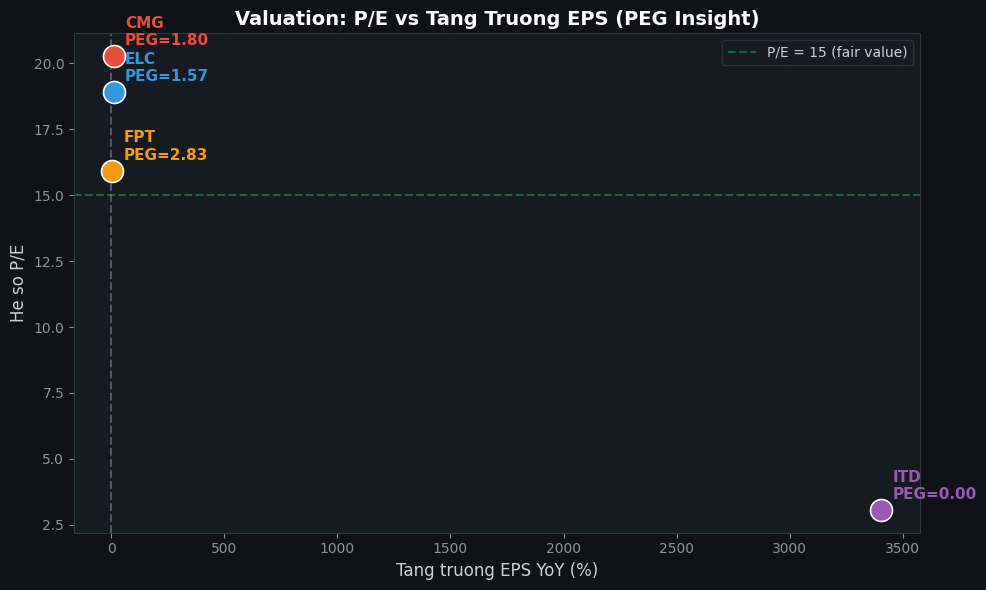

In [19]:
# ── Chart 1a: Scatter P/E vs EPS Growth (PEG insight) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for tk in TICKERS:
    row = df_m.loc[tk]
    ax.scatter(row['EPS_Growth_%'], row['P/E'], s=250, color=COLORS[tk],
               edgecolors='white', linewidths=1.2, zorder=5)
    ax.annotate(f"{tk}\nPEG={row['PEG']:.2f}" if not np.isnan(row['PEG']) else tk,
                (row['EPS_Growth_%'], row['P/E']),
                textcoords='offset points', xytext=(8, 8),
                color=COLORS[tk], fontsize=11, fontweight='bold')
ax.axvline(0, color='#8B949E', linestyle='--', alpha=0.5)
ax.axhline(15, color='#2ECC71', linestyle='--', alpha=0.4, label='P/E = 15 (fair value)')
ax.set_title('Valuation: P/E vs Tang Truong EPS (PEG Insight)', fontweight='bold', fontsize=14)
ax.set_xlabel('Tang truong EPS YoY (%)', fontsize=12)
ax.set_ylabel('He so P/E', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_01_valuation_scatter.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

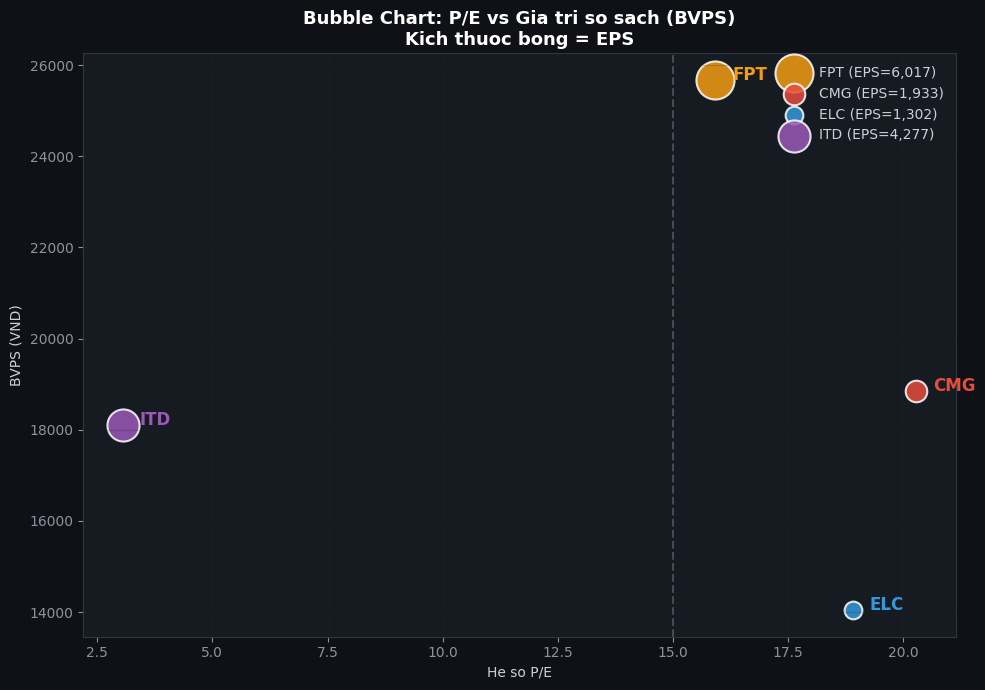

In [20]:
# ── Chart 1b: Bubble P/E vs BVPS (kích thước = EPS) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for tk in TICKERS:
    row = df_m.loc[tk]
    ax.scatter(row['P/E'], row['BVPS'], s=max(abs(row['EPS'])/8, 50),
               color=COLORS[tk], alpha=0.85, edgecolors='white', linewidths=1.5,
               label=f"{tk} (EPS={row['EPS']:,.0f})")
    ax.annotate(tk, (row['P/E'], row['BVPS']),
                textcoords='offset points', xytext=(12, 0),
                color=COLORS[tk], fontweight='bold', fontsize=12)
ax.axvline(15, color='#8B949E', linestyle='--', alpha=0.4)
ax.set_title('Bubble Chart: P/E vs Gia tri so sach (BVPS)\nKich thuoc bong = EPS', fontweight='bold', fontsize=13)
ax.set_xlabel('He so P/E'); ax.set_ylabel('BVPS (VND)')
ax.legend(frameon=False, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_02_valuation_bubble.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Nhóm 2 · Profitability — Hiệu Quả Sinh Lời

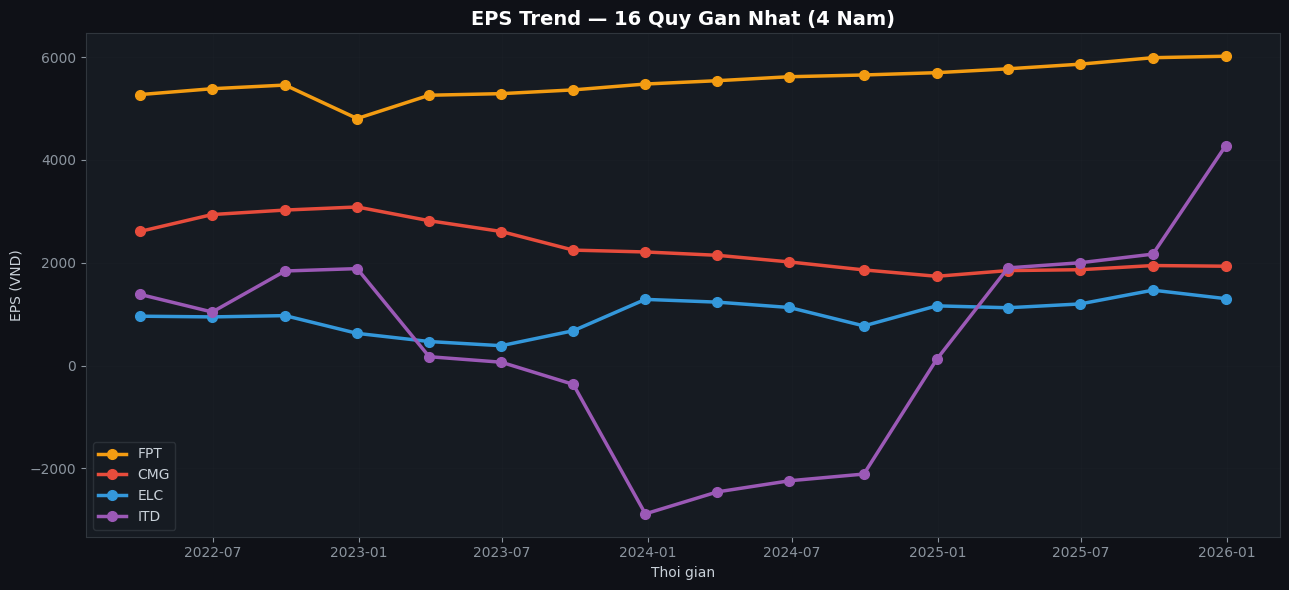

In [21]:
# ── Chart 2a: EPS Trend (16 quý gần nhất) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
for tk, df in dfs.items():
    dq = df[['date','EPS 4 quý']].drop_duplicates(subset=['EPS 4 quý'], keep='last').tail(16)
    ax.plot(dq['date'], dq['EPS 4 quý'], marker='o', linewidth=2.5,
            markersize=7, color=COLORS[tk], label=tk)
ax.set_title('EPS Trend — 16 Quy Gan Nhat (4 Nam)', fontweight='bold', fontsize=14)
ax.set_xlabel('Thoi gian'); ax.set_ylabel('EPS (VND)')
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_03_eps_trend.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

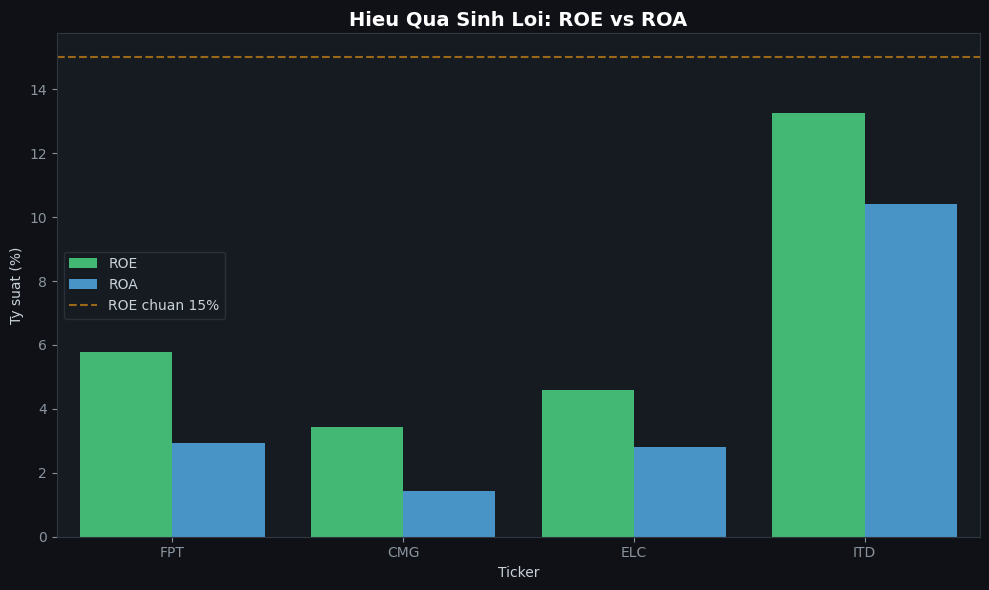

In [22]:
# ── Chart 2b: ROE & ROA Bar Chart ─────────────────────────────────────────────
df_ro = df_m[['ROE','ROA']].reset_index().rename(columns={'index':'Ticker'})
df_ro_melt = df_ro.melt(id_vars='Ticker', var_name='Metric', value_name='Value')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_ro_melt, x='Ticker', y='Value', hue='Metric',
            palette=['#2ECC71','#3498DB'], ax=ax)
ax.axhline(15, color='#F39C12', linestyle='--', alpha=0.6, label='ROE chuan 15%')
ax.set_title('Hieu Qua Sinh Loi: ROE vs ROA', fontweight='bold', fontsize=14)
ax.set_ylabel('Ty suat (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_04_roe_roa.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

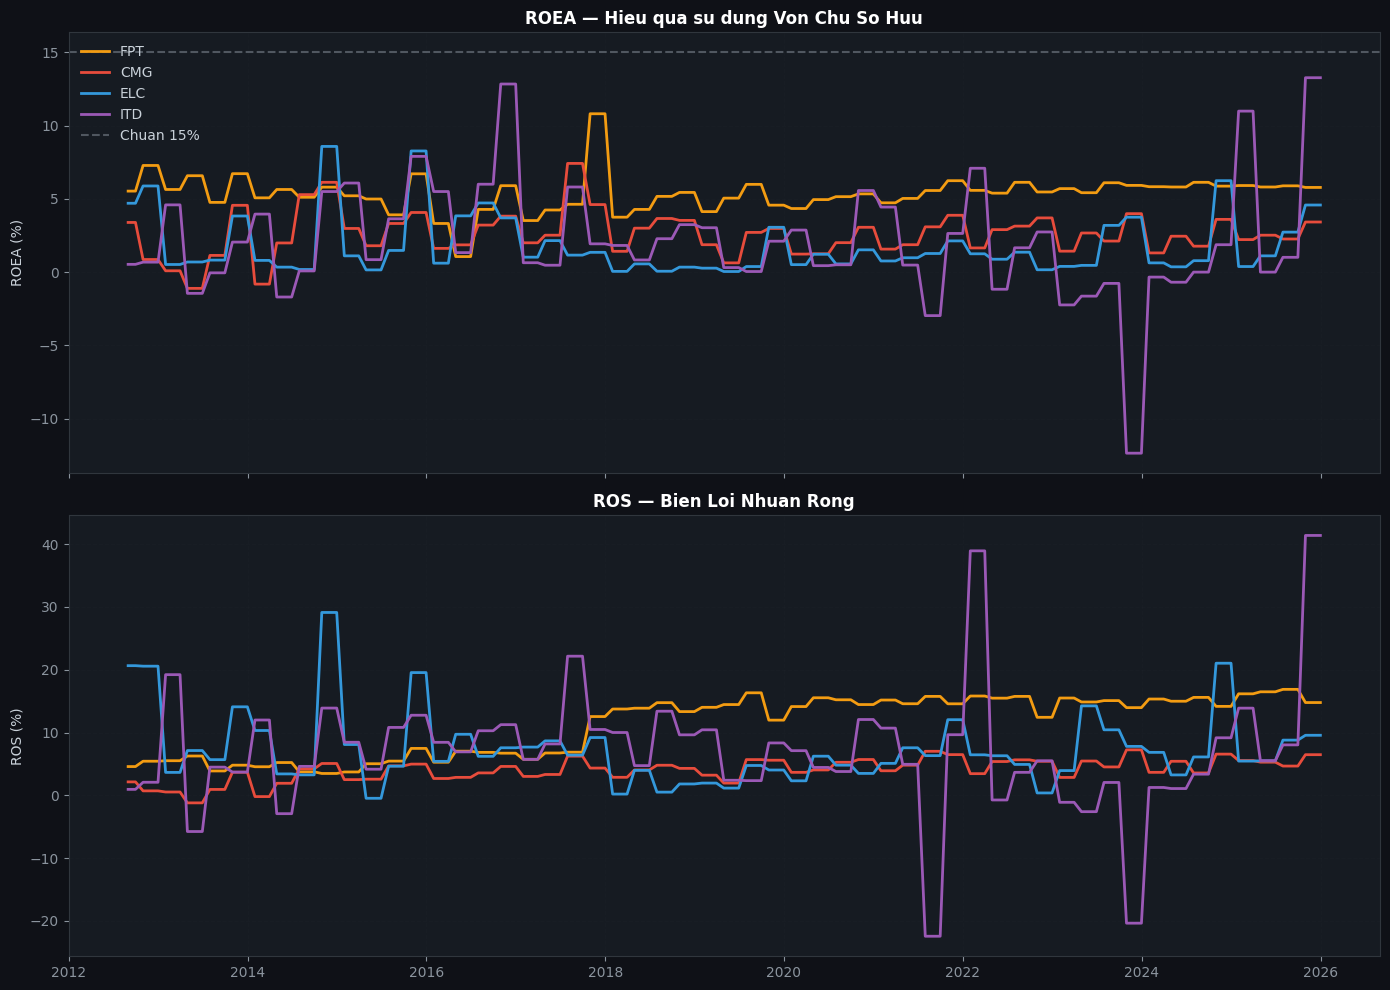

In [23]:
# ── Chart 2c: ROEA & ROS Trend (monthly) ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
# Gộp tất cả dữ liệu
all_df = pd.concat([df.assign(ticker=tk) for tk, df in dfs.items()], ignore_index=True)
monthly = all_df.groupby([pd.Grouper(key='date', freq='ME'), 'ticker']).last().reset_index()

for tk in TICKERS:
    data = monthly[monthly['ticker'] == tk]
    axes[0].plot(data['date'], data['ROEA'], color=COLORS[tk], label=tk, linewidth=2)
    axes[1].plot(data['date'], data['ROS'],  color=COLORS[tk], label=tk, linewidth=2)

axes[0].axhline(15, color='#8B949E', linestyle='--', alpha=0.5, label='Chuan 15%')
axes[0].set_title('ROEA — Hieu qua su dung Von Chu So Huu', fontweight='bold')
axes[0].set_ylabel('ROEA (%)')
axes[0].legend(loc='upper left', frameon=False)
axes[0].grid(True, linestyle='--', alpha=0.25)

axes[1].set_title('ROS — Bien Loi Nhuan Rong', fontweight='bold')
axes[1].set_ylabel('ROS (%)')
axes[1].grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_05_roea_ros_trend.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

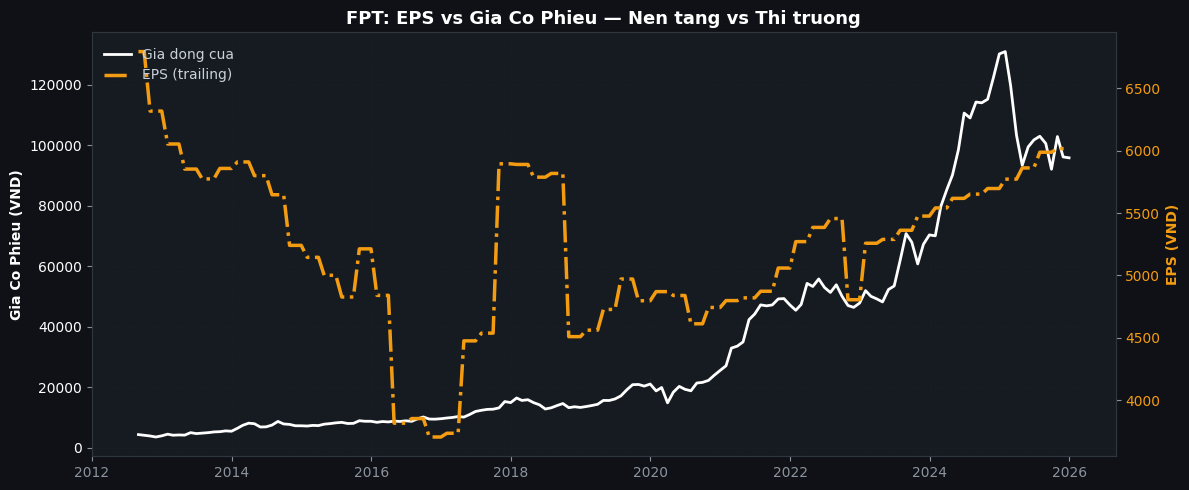

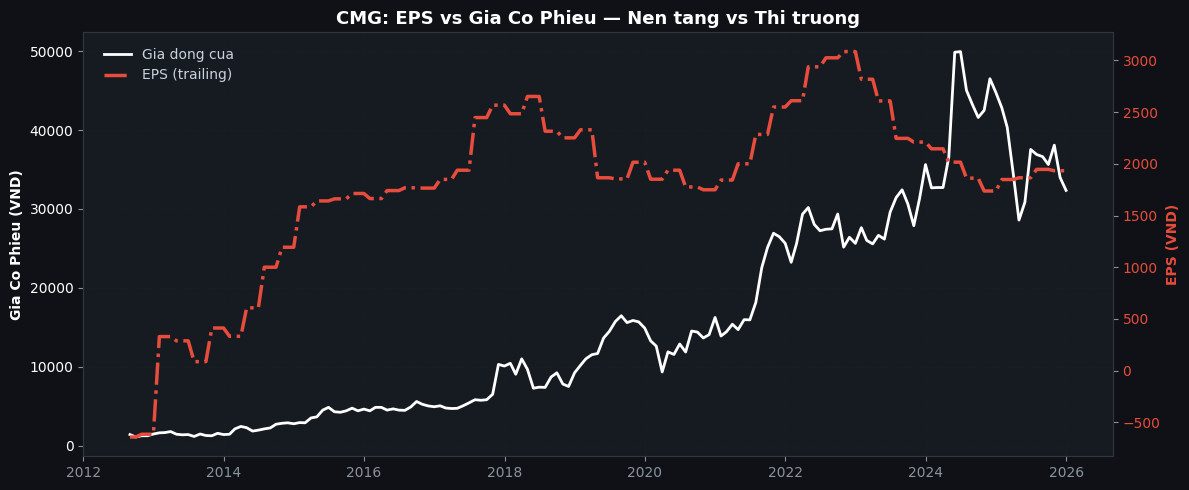

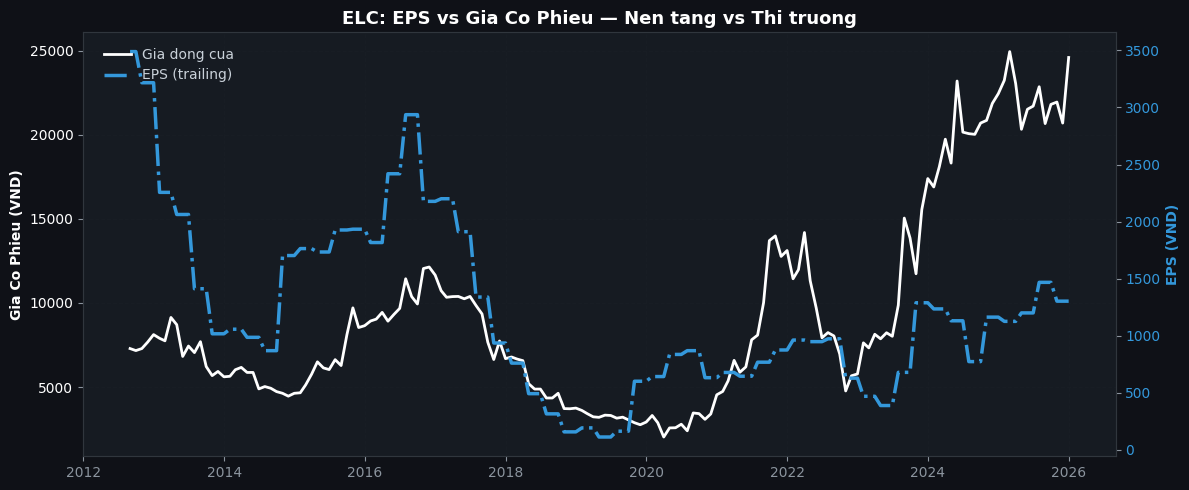

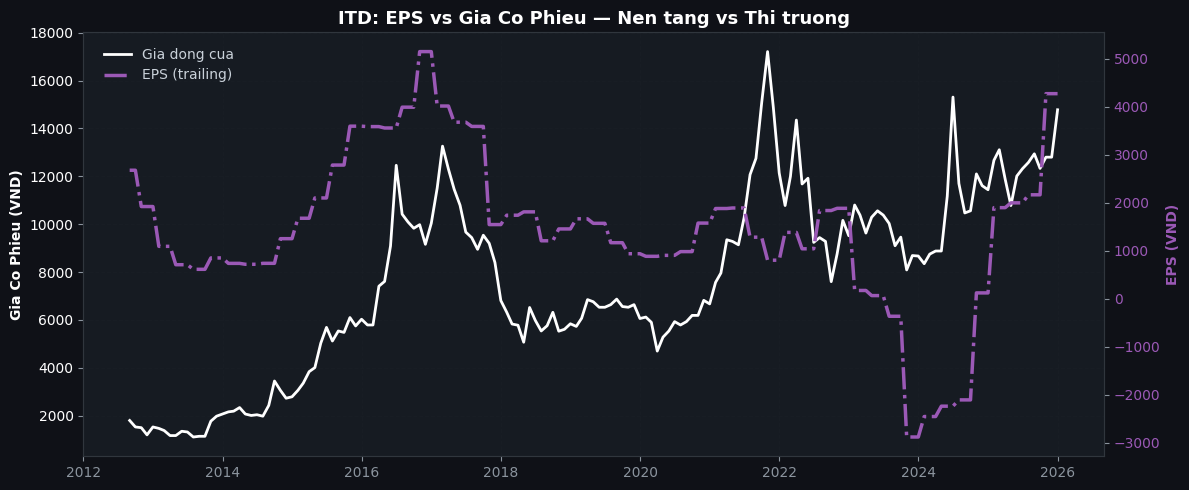

In [24]:
# ── Chart 2d: EPS vs Close Price (Dual Axis) — mỗi mã 1 chart ────────────────
for tk, df in dfs.items():
    monthly_tk = df.groupby(pd.Grouper(key='date', freq='ME')).last().reset_index()
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(monthly_tk['date'], monthly_tk['close'], color='#FFFFFF', linewidth=2, label='Gia dong cua')
    ax1.set_ylabel('Gia Co Phieu (VND)', color='#FFFFFF', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#FFFFFF')
    
    ax2 = ax1.twinx()
    ax2.plot(monthly_tk['date'], monthly_tk['EPS 4 quý'], color=COLORS[tk],
             linewidth=2.5, linestyle='-.', label='EPS (trailing)')
    ax2.set_ylabel('EPS (VND)', color=COLORS[tk], fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=COLORS[tk])
    
    plt.title(f'{tk}: EPS vs Gia Co Phieu — Nen tang vs Thi truong', fontweight='bold', fontsize=13, color='#FFFFFF')
    ax1.grid(True, linestyle='--', alpha=0.2)
    fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92), frameon=False)
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, f'fa_06_{tk.lower()}_eps_vs_price.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

---
## Nhóm 3 · Leverage & Liquidity — Sức Khỏe Tài Chính

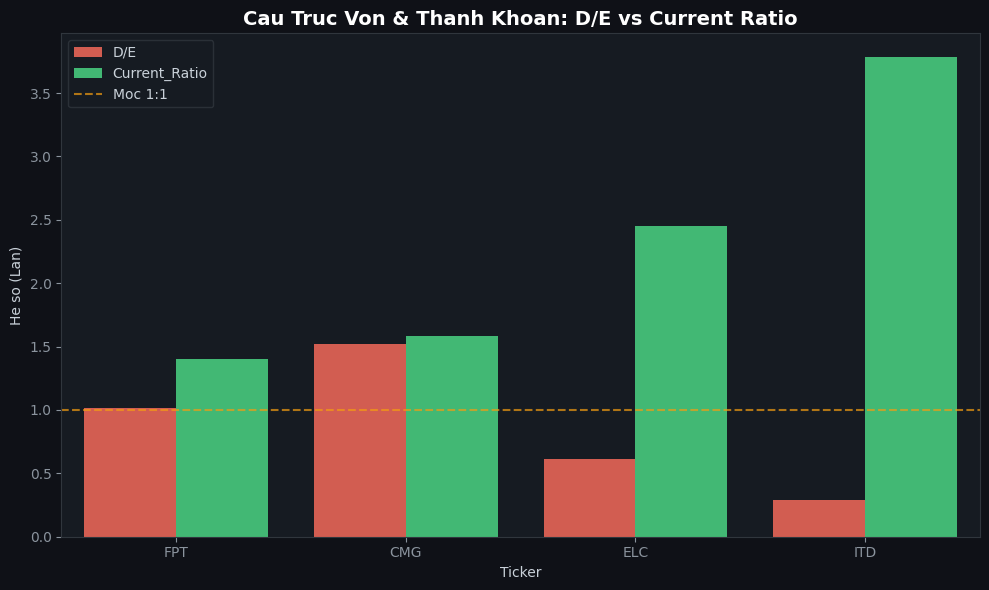

In [25]:
# ── Chart 3a: D/E vs Current Ratio ────────────────────────────────────────────
df_lev = df_m[['D/E','Current_Ratio']].reset_index().rename(columns={'index':'Ticker'})
df_lev_melt = df_lev.melt(id_vars='Ticker', var_name='Metric', value_name='Ratio')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_lev_melt, x='Ticker', y='Ratio', hue='Metric',
            palette=['#E74C3C','#2ECC71'], ax=ax)
ax.axhline(1.0, color='#F39C12', linestyle='--', alpha=0.7, label='Moc 1:1')
ax.set_title('Cau Truc Von & Thanh Khoan: D/E vs Current Ratio', fontweight='bold', fontsize=14)
ax.set_ylabel('He so (Lan)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_07_leverage.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [26]:
# ── Tính Beta vs VNINDEX ───────────────────────────────────────────────────────
def calc_beta(df_stock, df_market, window=252):
    merged = pd.merge(df_stock[['date','close']], df_market[['date','close']], on='date', suffixes=('_s','_m'))
    merged = merged.tail(window + 1).copy()
    merged['ret_s'] = merged['close_s'].pct_change()
    merged['ret_m'] = merged['close_m'].pct_change()
    merged = merged.dropna()
    cov = merged['ret_s'].cov(merged['ret_m'])
    var = merged['ret_m'].var()
    return cov / var if var != 0 else 1.0

betas = {tk: calc_beta(df, df_vni) for tk, df in dfs.items()}

# Cluster logic: Beta + D/E
def cluster(tk):
    b = betas[tk]; de = df_m.loc[tk, 'D/E']
    if b > 1.2 or de > 1.5:   return 'Tan cong / Rui ro cao'
    elif b < 1.0 and de < 1.0: return 'Phong thu / An toan'
    return 'Trung tinh'

df_m['Beta']    = pd.Series(betas)
df_m['Cluster'] = df_m.index.map(cluster)
display(df_m[['Beta','D/E','Current_Ratio','Cluster']].round(3))

,Beta,D/E,Current_Ratio,Cluster
FPT,0.783,1.013,1.398,Trung tinh
CMG,0.902,1.517,1.581,Tan cong / Rui ro cao
ELC,0.653,0.614,2.453,Phong thu / An toan
ITD,0.544,0.286,3.782,Phong thu / An toan


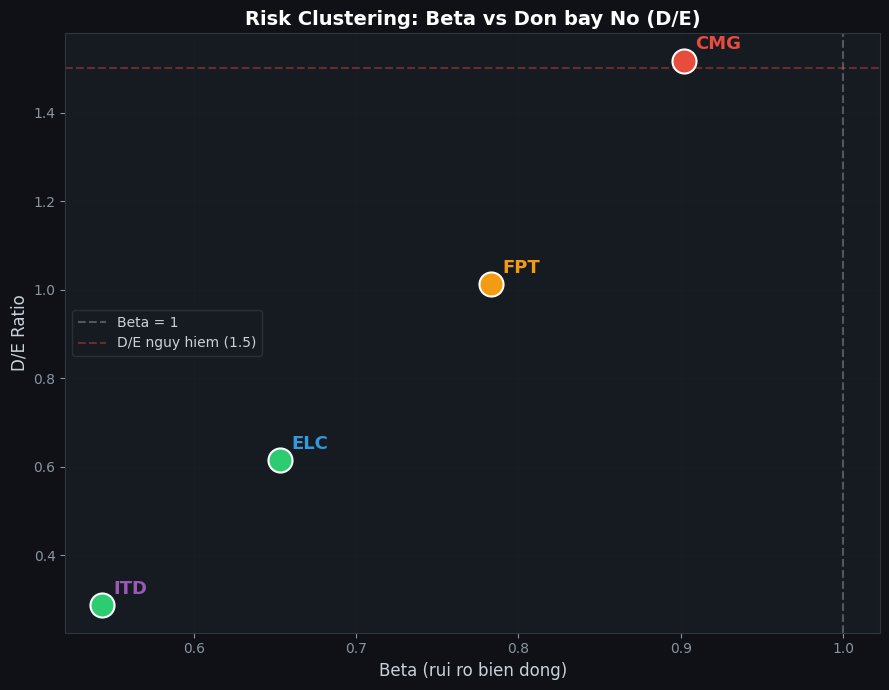

In [27]:
# ── Chart 3b: Risk Profile — Beta vs D/E Scatter ──────────────────────────────
cluster_colors = {'Tan cong / Rui ro cao': '#E74C3C', 'Phong thu / An toan': '#2ECC71', 'Trung tinh': '#F39C12'}

fig, ax = plt.subplots(figsize=(9, 7))
for tk in TICKERS:
    b  = df_m.loc[tk, 'Beta']
    de = df_m.loc[tk, 'D/E']
    cl = df_m.loc[tk, 'Cluster']
    ax.scatter(b, de, s=300, color=cluster_colors[cl], edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(tk, (b, de), textcoords='offset points', xytext=(8,8),
                color=COLORS[tk], fontsize=13, fontweight='bold')

ax.axvline(1.0, color='#8B949E', linestyle='--', alpha=0.5, label='Beta = 1')
ax.axhline(1.5, color='#E74C3C', linestyle='--', alpha=0.4, label='D/E nguy hiem (1.5)')
ax.set_title('Risk Clustering: Beta vs Don bay No (D/E)', fontweight='bold', fontsize=14)
ax.set_xlabel('Beta (rui ro bien dong)', fontsize=12)
ax.set_ylabel('D/E Ratio', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_08_beta_cluster.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Nhóm 4 · CANSLIM Scoring

In [28]:
# ── Tính điểm CANSLIM ─────────────────────────────────────────────────────────
# M: Market Direction
close_vn  = df_vni['close'].iloc[-1]
ma50_vn   = df_vni['close'].rolling(50).mean().iloc[-1]
ma200_vn  = df_vni['close'].rolling(200).mean().iloc[-1]
market_up = bool((close_vn > ma50_vn) and (close_vn > ma200_vn))
vni_1yr   = df_vni.iloc[-252]['close'] if len(df_vni) > 252 else df_vni.iloc[0]['close']
vni_ret   = (close_vn - vni_1yr) / vni_1yr

canslim_results = {}

for tk, df in dfs.items():
    # Fiscal-aware quarterly grouping
    if tk in ['ITD', 'CMG']:
        df['_q']  = df['date'].dt.month.map({4:1,5:1,6:1,7:2,8:2,9:2,10:3,11:3,12:3,1:4,2:4,3:4})
        df['_yr'] = np.where(df['date'].dt.month.isin([1,2,3]), df['date'].dt.year - 1, df['date'].dt.year)
    else:
        df['_q']  = df['date'].dt.quarter
        df['_yr'] = df['date'].dt.year

    quarterly = df.groupby(['_yr','_q']).last().reset_index()

    eps_q0 = quarterly['EPS 4 quý'].iloc[-1]
    eps_q1 = quarterly['EPS 4 quý'].iloc[-2]  if len(quarterly) >= 2 else eps_q0
    eps_q4 = quarterly['EPS 4 quý'].iloc[-5]  if len(quarterly) >= 5 else eps_q0
    roea   = quarterly['ROEA'].iloc[-1]

    cq_growth     = (eps_q0 - eps_q1) / abs(eps_q1) if eps_q1 != 0 else 0
    annual_growth = (eps_q0 - eps_q4) / abs(eps_q4) if eps_q4 != 0 else 0

    last_252    = df.tail(252)
    high_52w    = last_252['close'].max()
    curr_close  = df.iloc[-1]['close']
    dist_high   = (high_52w - curr_close) / high_52w
    curr_vol    = df.iloc[-1]['volume']
    ma50_vol    = df.tail(50)['volume'].mean()
    close_1yr   = df.iloc[-252]['close'] if len(df) > 252 else df.iloc[0]['close']
    rs_alpha    = (curr_close - close_1yr) / close_1yr - vni_ret

    canslim_results[tk] = {
        'C (+20%)': f"{cq_growth*100:+.1f}%",  'C Pass': cq_growth > 0.20,
        'A (+20%)': f"{annual_growth*100:+.1f}%", 'A Pass': annual_growth > 0.20,
        'N (<5% of hi)': f"{dist_high*100:.1f}%", 'N Pass': dist_high <= 0.05,
        'S (vol>avg)':   f"{curr_vol/ma50_vol:.2f}x", 'S Pass': curr_vol > ma50_vol,
        'L (RS>VNI)':    f"{rs_alpha*100:+.1f}%",  'L Pass': rs_alpha > 0,
        'I (ROE>=15)':   f"{roea:.2f}%",          'I Pass': roea >= 15.0,
        'M (Uptrend)':   'Uptrend' if market_up else 'Down/Side', 'M Pass': market_up,
    }

df_can = pd.DataFrame(canslim_results).T
pass_cols = [c for c in df_can.columns if c.endswith('Pass')]
df_can['SCORE'] = df_can[pass_cols].apply(lambda r: r.sum(), axis=1).astype(str) + '/7'
display(df_can)

,C (+20%),C Pass,A (+20%),A Pass,N (<5% of hi),N Pass,S (vol>avg),S Pass,L (RS>VNI),L Pass,I (ROE>=15),I Pass,M (Uptrend),M Pass,SCORE
FPT,+0.5%,False,+5.6%,False,27.2%,False,0.43x,False,-79.8%,False,5.78%,False,Down/Side,False,False/7
CMG,-0.7%,False,+11.3%,False,27.9%,False,0.63x,False,-81.6%,False,3.42%,False,Down/Side,False,False/7
ELC,-11.2%,False,+12.0%,False,5.4%,False,1.67x,True,-45.5%,False,4.58%,False,Down/Side,False,True/7
ITD,+97.3%,True,+3405.7%,True,8.1%,False,0.57x,False,-25.7%,False,13.27%,False,Down/Side,False,True/7


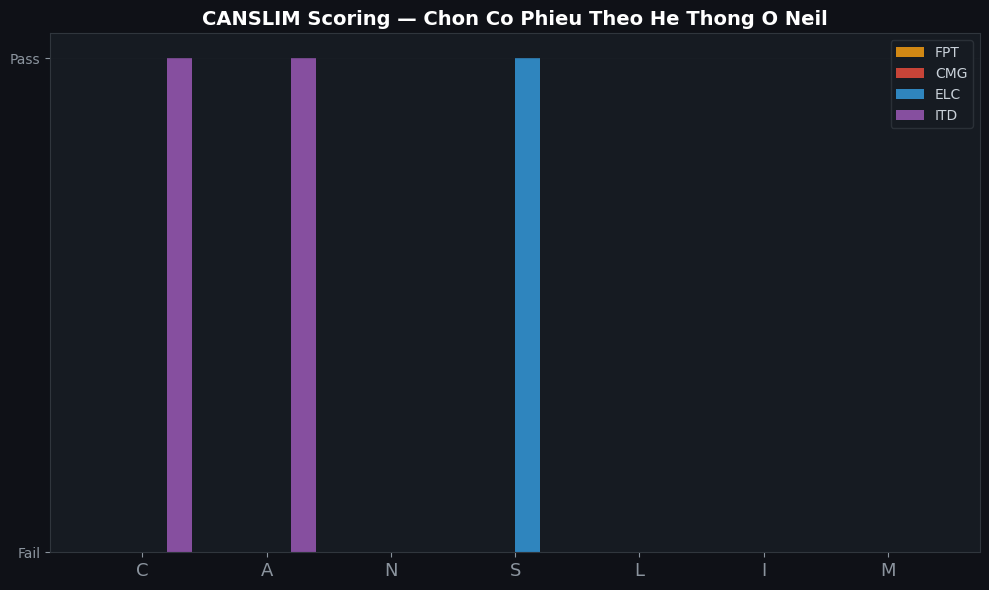


CANSLIM Summary:
  FPT: False/7 criteria passed
  CMG: False/7 criteria passed
  ELC: True/7 criteria passed
  ITD: True/7 criteria passed


In [29]:
# ── Chart 4: CANSLIM Radar / Bar ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
criteria = ['C Pass','A Pass','N Pass','S Pass','L Pass','I Pass','M Pass']
labels   = ['C','A','N','S','L','I','M']
x = np.arange(len(labels))
width = 0.2
for i, tk in enumerate(TICKERS):
    vals = [int(canslim_results[tk][c]) for c in criteria]
    ax.bar(x + i * width, vals, width, label=tk, color=COLORS[tk], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Fail', 'Pass'])
ax.set_title('CANSLIM Scoring — Chon Co Phieu Theo He Thong O Neil', fontweight='bold', fontsize=14)
ax.legend(); ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'fa_09_canslim.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('\nCANSLIM Summary:')
for tk in TICKERS:
    print(f"  {tk}: {df_can.loc[tk, 'SCORE']} criteria passed")